In [3]:
import os, sys
os.chdir(os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))  # ensure project root
sys.path.insert(0, os.getcwd())
from src import model
import matplotlib.pyplot as plt
import gurobipy
import numpy as np
import os
import pypsa

In [4]:
%%capture
# run models with different max caps
#current emissions aprox. 60 000l*2.65kg CO2e/l= 159t CO2e (with installed capacities?)
initial_price = 0.1
increment_step =0.025
emission=250

diesel_models = {}
for diesel_price_ in np.arange(initial_price, 0.4, increment_step):
    diesel_models[f"diesel_model_{round(diesel_price_, 2)}"] = model.main(emission, diesel_price_)


save models in local "models folder"

In [5]:
folder_name = "models_diesel_existing"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)
for model_name, network in diesel_models.items():
    print(model_name)
    print(network)
    filename = os.path.join(folder_name, f"{model_name}.nc")  # For NetCDF format
    # Assuming 'model_instance' is a PyPSA Network object
    network.export_to_netcdf(filename)

diesel_model_0.1
PyPSA Network
Components:
 - Bus: 5
 - Carrier: 6
 - Generator: 11
 - GlobalConstraint: 1
 - Link: 8
 - Load: 2
 - Store: 5
Snapshots: 8760
diesel_model_0.12
PyPSA Network
Components:
 - Bus: 5
 - Carrier: 6
 - Generator: 11
 - GlobalConstraint: 1
 - Link: 8
 - Load: 2
 - Store: 5
Snapshots: 8760
diesel_model_0.15
PyPSA Network
Components:
 - Bus: 5
 - Carrier: 6
 - Generator: 11
 - GlobalConstraint: 1
 - Link: 8
 - Load: 2
 - Store: 5
Snapshots: 8760
diesel_model_0.18
PyPSA Network
Components:
 - Bus: 5
 - Carrier: 6
 - Generator: 11
 - GlobalConstraint: 1
 - Link: 8
 - Load: 2
 - Store: 5
Snapshots: 8760
diesel_model_0.2
PyPSA Network
Components:
 - Bus: 5
 - Carrier: 6
 - Generator: 11
 - GlobalConstraint: 1
 - Link: 8
 - Load: 2
 - Store: 5
Snapshots: 8760
diesel_model_0.22
PyPSA Network
Components:
 - Bus: 5
 - Carrier: 6
 - Generator: 11
 - GlobalConstraint: 1
 - Link: 8
 - Load: 2
 - Store: 5
Snapshots: 8760
diesel_model_0.25
PyPSA Network
Components:
 - Bus: 5


load models

In [6]:

# Define the folder where the models are saved
folder_name = "models_existing_co2"

# Initialize the dictionary to store the loaded models
emission_models = {}

# List all files in the folder
for filename in os.listdir(folder_name):
    if filename.endswith(".nc"):
        # Construct the full path to the file
        file_path = os.path.join(folder_name, filename)
        
        # Load the model using PyPSA
        model_instance = pypsa.Network(file_path)
        
        # Extract the model name from the filename (without the extension)
        model_name = os.path.splitext(filename)[0]
        
        # Store the model in the dictionary
        emission_models[model_name] = model_instance

# Print out the loaded model names to verify
print("Models loaded into the dictionary:")
for model_name in emission_models:
    print(model_name)

c:\Miniconda3\envs\pypsa-longyearbyen\Lib\site-packages\pypsa\components.py:323: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  attrs.loc[bool_b, "default"] = attrs.loc[bool_b].isin({True, "True"})
c:\Miniconda3\envs\pypsa-longyearbyen\Lib\site-packages\pypsa\components.py:323: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  attrs.loc[bool_b, "default"] = attrs.loc[bool_b].isin({True, "True"})
c:\Miniconda3\envs\pypsa-longyearbyen\Lib\site-packages\pypsa\components.py:323: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64,

Models loaded into the dictionary:
emissions_models_0
emissions_model_10
emissions_model_15
emissions_model_20
emissions_model_25
emissions_model_30
emissions_model_35
emissions_model_40
emissions_model_45
emissions_model_5
emissions_model_50
emissions_model_55
emissions_model_60


c:\Miniconda3\envs\pypsa-longyearbyen\Lib\site-packages\pypsa\components.py:323: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  attrs.loc[bool_b, "default"] = attrs.loc[bool_b].isin({True, "True"})
c:\Miniconda3\envs\pypsa-longyearbyen\Lib\site-packages\pypsa\components.py:323: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  attrs.loc[bool_b, "default"] = attrs.loc[bool_b].isin({True, "True"})
c:\Miniconda3\envs\pypsa-longyearbyen\Lib\site-packages\pypsa\components.py:323: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64,

In [7]:
import pandas as pd
import numpy as np

lcoe_results = []
discount_rate = 0.06  # 6%

for idx, (model_name, network) in enumerate(diesel_models.items()):
    diesel_price_str = model_name.split('_')[-1]
    diesel_price = float(diesel_price_str)
    
    print(f"Processing {model_name} with diesel price {diesel_price} €/MWh")
    
    diesel_generator_name = "Diesel_import-existing"
    if diesel_generator_name in network.generators.index:
        network.generators.at[diesel_generator_name, 'marginal_cost'] = diesel_price
    generators = network.generators
    generators_t = network.generators_t

    total_annualized_cost = 0
    total_energy_produced = 0

    # Compute costs for each generator
    for gen in generators.index:
        p_nom_opt = generators.p_nom_opt.at[gen]
        capital_cost_per_mw = generators.at[gen, 'capital_cost']
        capital_cost = capital_cost_per_mw * p_nom_opt

        # Get or assume lifetime
        if 'lifetime' in generators.columns and not pd.isna(generators.at[gen, 'lifetime']):
            lifetime = generators.at[gen, 'lifetime']
        else:
            lifetime = 25  # Default 25 years

        # Calculate Capital Recovery Factor (CRF)
        crf = (discount_rate * (1 + discount_rate) ** lifetime) / ((1 + discount_rate) ** lifetime - 1)

        # Annualized capital expenditure
        annualized_capex = capital_cost * crf

        # Fixed O&M cost
        if 'fixed_cost' in generators.columns and not pd.isna(generators.at[gen, 'fixed_cost']):
            fixed_opex = generators.at[gen, 'fixed_cost'] * p_nom_opt
        elif 'FOM' in generators.columns and not pd.isna(generators.at[gen, 'FOM']):
            # If FOM is given as a percentage of CapEx
            fixed_opex = generators.at[gen, 'FOM'] * capital_cost
        else:
            fixed_opex = 0

        # Variable O&M cost
        total_gen_output = generators_t.p[gen].sum()
        marginal_cost = generators.at[gen, 'marginal_cost']
        variable_opex = marginal_cost * total_gen_output

        # Total annual cost for generator
        annual_cost_gen = annualized_capex + fixed_opex + variable_opex
        total_annualized_cost += annual_cost_gen
        total_energy_produced += total_gen_output

    # Compute costs for each storage unit
    for storage in network.stores.index:
        e_nom = network.stores.at[storage, 'e_nom']
        capital_cost_per_mwh = network.stores.at[storage, 'capital_cost']
        capital_cost = capital_cost_per_mwh * e_nom
        storage_total_cost = annualized_capex
        total_annualized_cost += storage_total_cost

    # Compute overall LCOE for the network
    if total_energy_produced > 0:
        overall_lcoe = total_annualized_cost / total_energy_produced
    else:
        overall_lcoe = float('inf')  # Handle zero energy production

    print(f"{model_name}: Overall LCOE = {overall_lcoe:.2f} €/MWh")

    # Store the results
    lcoe_results.append({
        'model_name': model_name,
        'diesel_price': diesel_price,
        'lcoe': overall_lcoe,
        'total_annualized_cost': total_annualized_cost,
        'total_energy_produced': total_energy_produced
    })

# Convert results to DataFrame
lcoe_df = pd.DataFrame(lcoe_results)
print(lcoe_df)


Processing diesel_model_0.1 with diesel price 0.1 €/MWh
diesel_model_0.1: Overall LCOE = nan €/MWh
Processing diesel_model_0.12 with diesel price 0.12 €/MWh
diesel_model_0.12: Overall LCOE = nan €/MWh
Processing diesel_model_0.15 with diesel price 0.15 €/MWh
diesel_model_0.15: Overall LCOE = nan €/MWh
Processing diesel_model_0.18 with diesel price 0.18 €/MWh
diesel_model_0.18: Overall LCOE = nan €/MWh
Processing diesel_model_0.2 with diesel price 0.2 €/MWh
diesel_model_0.2: Overall LCOE = nan €/MWh
Processing diesel_model_0.22 with diesel price 0.22 €/MWh
diesel_model_0.22: Overall LCOE = nan €/MWh
Processing diesel_model_0.25 with diesel price 0.25 €/MWh
diesel_model_0.25: Overall LCOE = nan €/MWh
Processing diesel_model_0.27 with diesel price 0.27 €/MWh
diesel_model_0.27: Overall LCOE = nan €/MWh
Processing diesel_model_0.3 with diesel price 0.3 €/MWh
diesel_model_0.3: Overall LCOE = nan €/MWh
Processing diesel_model_0.32 with diesel price 0.32 €/MWh
diesel_model_0.32: Overall LCOE =

C:\Users\Kai Koepchen#\AppData\Local\Temp\ipykernel_15328\837124164.py:35: RuntimeWarning: invalid value encountered in scalar divide
  crf = (discount_rate * (1 + discount_rate) ** lifetime) / ((1 + discount_rate) ** lifetime - 1)


In [9]:
exchange_rate=11.92
diesel_price = []
renew_share  = []
SWP_capacity_installed=[]
for name, network in diesel_models.items():
    price = ((name.split('_')[-1]))
    diesel_price.append(price)
    renewable_generators = network.generators[network.generators.carrier.isin(["solar", "wind", "hydrogen", "heat pump"])]
    renewable_installed_capacity=renewable_generators.p_nom_opt.sum()
    diesel_generators=network.generators[network.generators.carrier.isin(["diesel"])]
    diesel_installed=diesel_generators.p_nom_opt.sum()
    total_installed_capacity = renewable_installed_capacity+diesel_installed #otherwise the load curtailment gets added to the total capacity!
    renewable_share = renewable_installed_capacity / total_installed_capacity
    print(renewable_share)
    renew_share.append(renewable_share)
    SWP_capacity_installed.append(network.generators.p_nom_opt.loc["SWP turbine"])
    

print(renew_share)


0.49471052513747465
0.5007525670777265
0.5036162675522675
0.5070754189865732
0.5087546219625874
0.5114843333978131
0.515170361689602
0.5185290664544328
0.5197032098971034
0.5207540155374473
0.5218123164084669
0.5233619540599317
0.5239882576716088
[np.float64(0.49471052513747465), np.float64(0.5007525670777265), np.float64(0.5036162675522675), np.float64(0.5070754189865732), np.float64(0.5087546219625874), np.float64(0.5114843333978131), np.float64(0.515170361689602), np.float64(0.5185290664544328), np.float64(0.5197032098971034), np.float64(0.5207540155374473), np.float64(0.5218123164084669), np.float64(0.5233619540599317), np.float64(0.5239882576716088)]


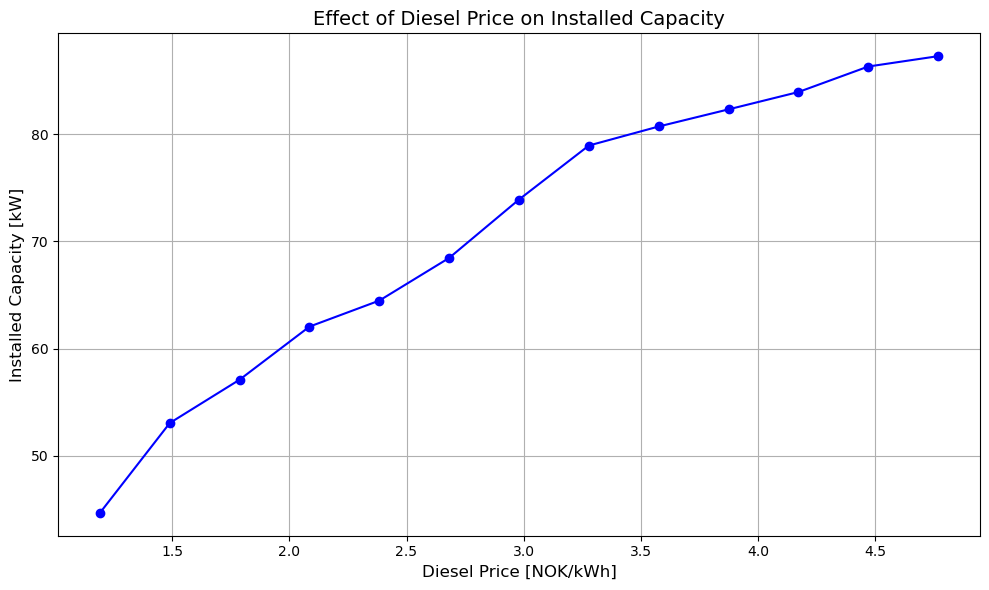

In [10]:
exchange_rate=11.92
diesel_price = [0.1, 0.125, 0.15, 0.175, 0.2, 0.225, 0.25,0.275,0.3,0.325,0.35,0.375,0.4]  # Example diesel prices in the local currency
diesel_price_ex=[exchange_rate * element for element in diesel_price]
plt.figure(figsize=(10, 6))
plt.plot(diesel_price_ex, SWP_capacity_installed, marker='o', linestyle='-', color='b')
plt.xlabel('Diesel Price [NOK/kWh]', fontsize=12)
plt.ylabel('Installed Capacity [kW]', fontsize=12)
plt.title('Effect of Diesel Price on Installed Capacity', fontsize=14)
plt.grid(True)
plt.tight_layout()

plt.savefig('installed_capacity_vs_diesel_price.png', dpi=300)

plt.show()
